# Цель анализа

Цель исследования – оценить влияние различных факторов на эффективность работы сотрудников компании.

Для достижения цели необходимо провести анализ статистических данных о сотрудниках компании, включая возраст, образование, стаж, показатели KPI, участие в обучении и награды. Результаты исследования могут быть использованы для построения аналитических моделей, например, модели прогнозирования повышения, которая позволит отделу HR принимать более обоснованные решения о развитии и продвижении персонала.

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt

# Обзор данных

В качестве объекта исследования выбран датасет «HR Analysis Case Study», содержащий сведения о возрасте, образовании, стаже, выполнении KPI, наградах, участии в тренингах, рейтинге за предыдущий год и других характеристиках, собранный дата-сайентистом из Индии.

Для начала загрузим датасет

In [2]:
# Загрузка данных
df = pd.read_csv("data.csv")

Посмотрим, сколько строк и столбцов содержит таблица

In [3]:
# Проверяем размерность датасета (строки, столбцы)
df.shape

(23490, 13)

Результат показывает количество записей и признаков.

Просмотрим содержимое первых 10 строк:

In [4]:
# Просматриваем первые 10 строк, чтобы понять структуру данных
df.head(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
5,46232,Procurement,region_7,Bachelor's,m,sourcing,1,36,3.0,2,0,0,68
6,54542,Finance,region_2,Bachelor's,m,other,1,33,5.0,3,1,0,57
7,67269,Analytics,region_22,Bachelor's,m,sourcing,2,36,3.0,3,0,0,85
8,66174,Technology,region_7,Master's & above,m,other,1,51,4.0,11,0,0,75
9,76303,Technology,region_22,Bachelor's,m,sourcing,1,29,5.0,2,1,0,76


Проверим типы данных и наличие пропусков:

In [5]:
# Проверка типов данных, количество непустых значений
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


Здесь видно, что часть столбцов имеет тип object, а числовые признаки представлены в int64 и float64. Некоторые признаки содержат пропуски (education, previous_year_rating).

Проверим базовые статистические характеристики (среднее, минимум, максимум, стандартное отклонение):

In [6]:
# Проверка базовых статистических характеристик
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


# Предобработка данных

Приведем имена столбцов к единому формату (snake_case) и уберем спецсимволы (?, %, >). Это улучшит читаемость и может предотвратить ошибки при обращении к столбцам.

In [7]:
# Приводим имена к единому стилю, убираем спецсимволы
df.rename(columns={
    'no_of_trainings': 'trainings_count',
    'length_of_service': 'service_years',
    'KPIs_met >80%': 'kpi_met_80',
    'awards_won?': 'awards_won'
}, inplace=True)

Преобразуем категориальные признаки. Пол приведен к полным английским словам для удобства. Значения образования унифицированы и переведены в нижний регистр.

In [8]:
# Приводим обозначения пола к понятному виду
df['gender'] = df['gender'].replace({'m': 'male', 'f': 'female'})

In [9]:
# Приводим уровни образования к нижнему регистру и стандартным названиям
df['education'] = df['education'].str.lower().replace({
    "bachelor's": 'bachelor',
    "master's & above": 'master',
    "secondary": 'secondary'
})

Проверим количество пропусков:

In [10]:
# Проверка количества пропусков в каждом столбце
df.isna().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
trainings_count            0
age                        0
previous_year_rating    1812
service_years              0
kpi_met_80                 0
awards_won                 0
avg_training_score         0
dtype: int64

Пропуски обнаружены в двух признаках: education и previous_year_rating.

Заменим пропуски в previous_year_rating 0, что обозначает отсутствие оценки. Давать оценку от 1 до 5 будет некорректно, потому что сотрудник еще не оценивался. В education пропуски заменим на 'secondary', так как такие сотрудники, вероятно, имеют среднее образование, учитывая особенности образования в Индии.

In [11]:
# Заполняем пропуски в рейтинге за прошлый год нулями (0 = нет оценки)
df['previous_year_rating'].fillna(0, inplace=True)

C:\Users\Pelmeshka\AppData\Local\Temp\ipykernel_21624\2756497283.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(0, inplace=True)


In [12]:
# Заполняем пропуски в образовании: считаем, что это среднее образование
df['education'].fillna('secondary', inplace=True)

C:\Users\Pelmeshka\AppData\Local\Temp\ipykernel_21624\3200722845.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna('secondary', inplace=True)


После этого проверяем, остались ли пропуски:

In [13]:
# Проверяем, остались ли пропуски в датасете
int(df.isna().sum().sum())

0

Преобразуем типы данных, так как оценка должна быть целочисленной (0-5).

In [14]:
# Преобразуем рейтинг из float в int
df['previous_year_rating'] = df['previous_year_rating'].astype(int)

Проверим датасет на дубликаты:

In [15]:
# Проверка дубликатов
int(df.duplicated().sum())

0

Удалим идентификатор сотрудника. Поле employee_id не несёт аналитической нагрузки, поэтому удалено, чтобы не мешать анализу.

In [16]:
# Удаляем идентификатор сотрудника
df.drop(columns='employee_id', inplace=True)

Контрольная проверка структуры данных:

In [17]:
# Контрольная проверка данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   department            23490 non-null  object
 1   region                23490 non-null  object
 2   education             23490 non-null  object
 3   gender                23490 non-null  object
 4   recruitment_channel   23490 non-null  object
 5   trainings_count       23490 non-null  int64 
 6   age                   23490 non-null  int64 
 7   previous_year_rating  23490 non-null  int64 
 8   service_years         23490 non-null  int64 
 9   kpi_met_80            23490 non-null  int64 
 10  awards_won            23490 non-null  int64 
 11  avg_training_score    23490 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 2.2+ MB


Визуализируем распределения признаков:

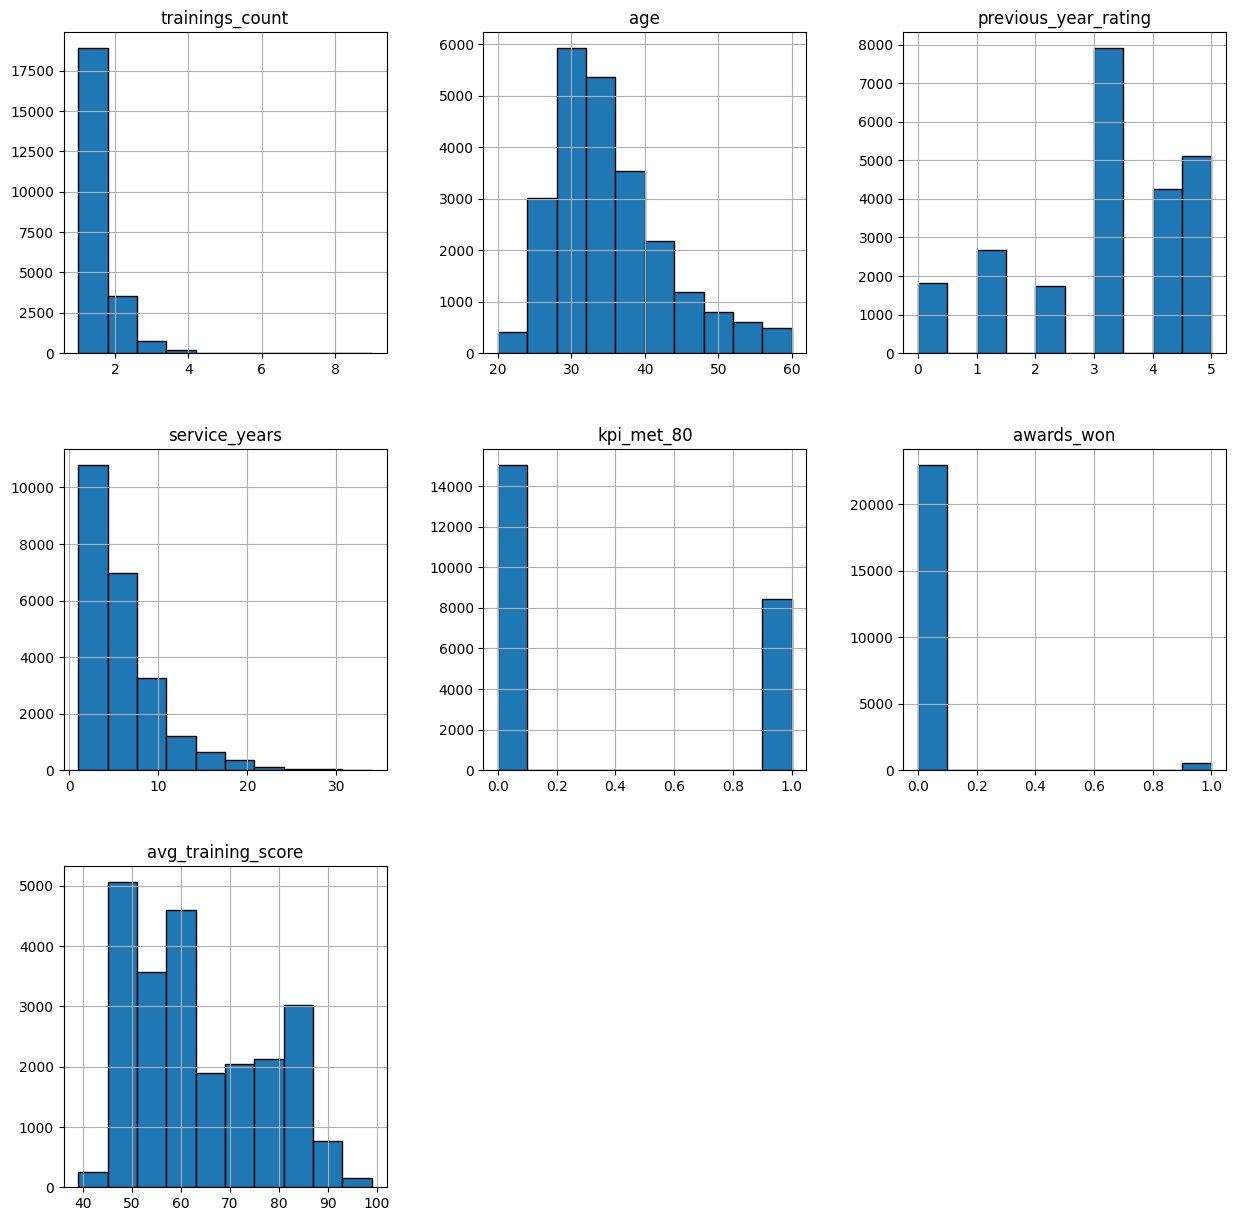

In [18]:
# Визуализация распределения
df.hist(edgecolor='black', linewidth=1, figsize=(15, 15))
plt.show()

# Заключение

В ходе выполнения лабораторной работы был проведен анализ и предобработка данных о сотрудниках компании. Данные были загружены, исследованы и очищены от пропусков и дубликатов. Названия столбцов и категориальные признаки были приведены к единому формату.

**Наблюдения по распределениям:**
- Распределение количества посещенных тренингов (trainings_count) резко скошено влево: подавляющее большинство сотрудников проходили 1-2 тренинга.
- Распределение возраста (age) близко к нормальному, с пиком в диапазоне 30-35 лет.
- Наибольшее количество сотрудников имеют рейтинг 3-5 (previous_year_rating).
- Распределение стажа (service_years) скошено влево: пик на уровне 3-5 лет.
- Около 60% сотрудников не достигли порога 80% KPI, а 40% выполнили KPI (kpi_met_80).
- Подавляющее большинство сотрудников не получали награды (awards_won).
- У большинства сотрудников результаты обучения выше 50, средний балл около 60 (avg_training_score).

**Рекомендации заказчику:**
- В источнике данных отсутствует единый формат записи образования: рекомендуется ограничить ввод через выпадающий список.
- Поле KPI стоит хранить не только в виде флага, но и в виде процента.